In [ ]:
# 某连锁店销售订单统计分析
# 需求1：统计每天销售额的变化。（折线图）
# 需求2：统计对比不同城市的累计销售数量。（柱状图）
# 需求3：统计不同产品类型对应的订单比例。（饼状图）
# 需求4：统计不同支付方式对应的订单比例。（饼状图）
# 数据分析：nopan Hadoop sql

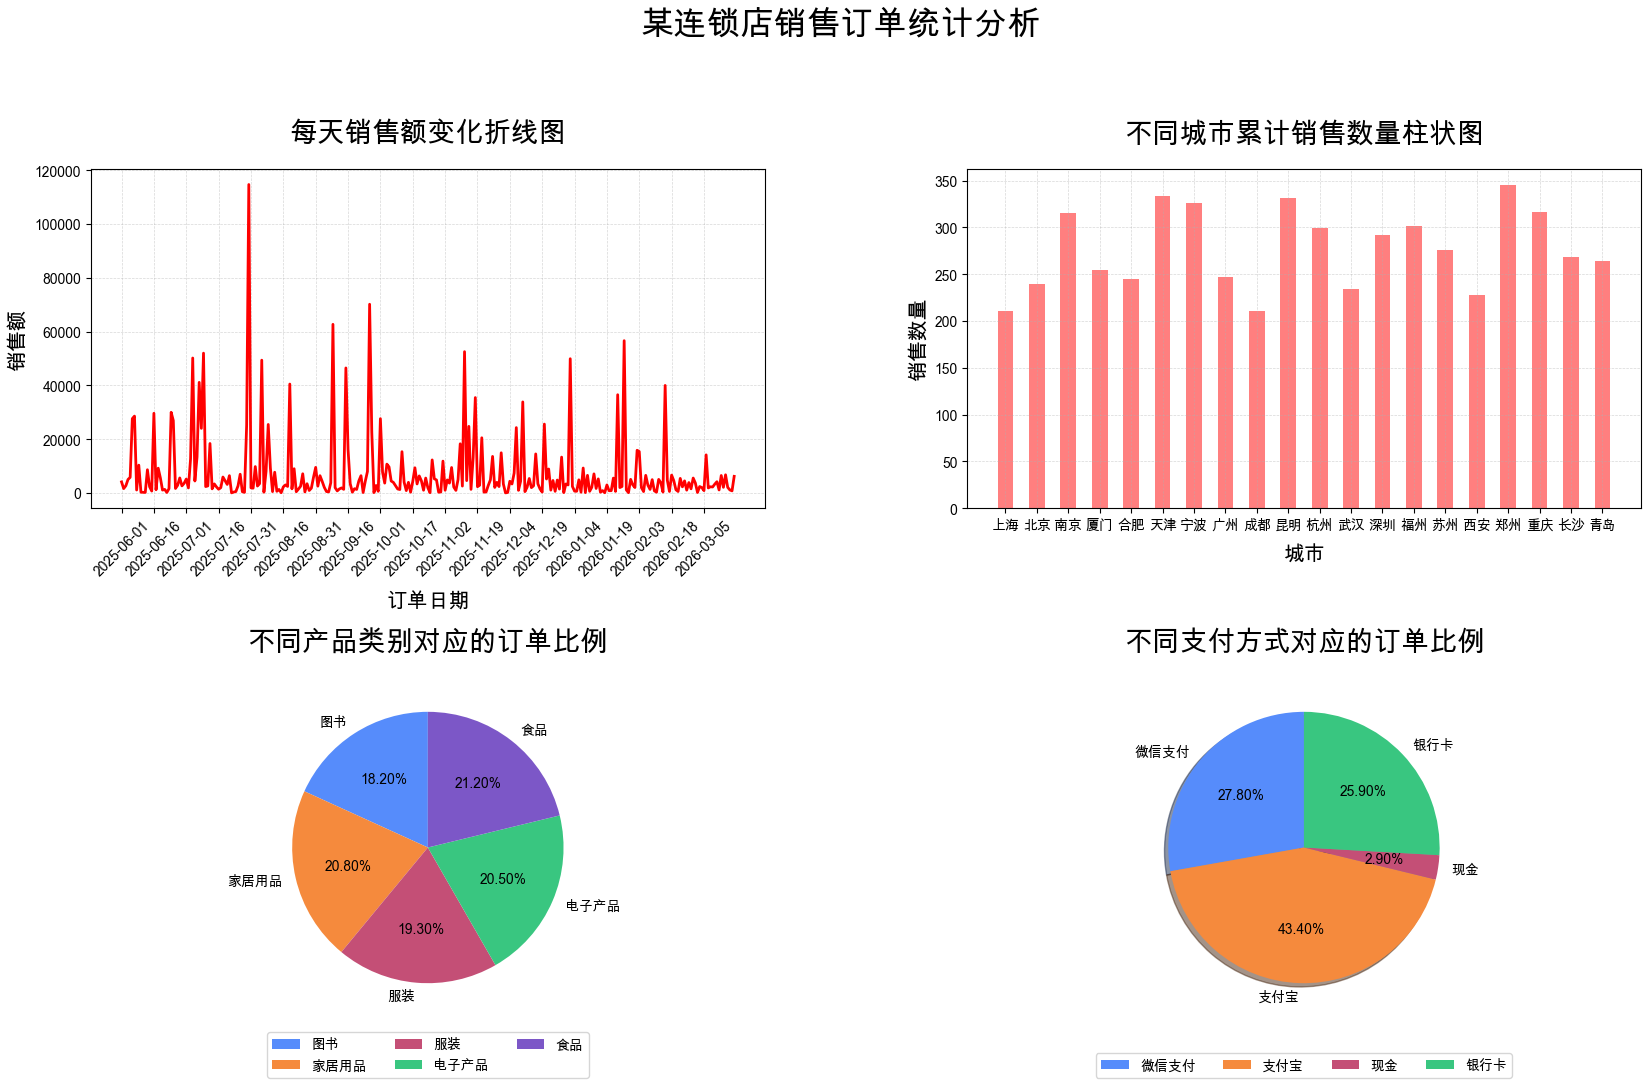

In [66]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

# 支持中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

fig,ax = plt.subplots(ncols=2, nrows=2, figsize=(20,16), dpi=100)
fig.suptitle('某连锁店销售订单统计分析', fontsize=24)
plt.subplots_adjust(wspace=0.3, hspace=0.5, bottom=0.35)

axes1:Axes = ax[0][0]
axes2:Axes = ax[0][1]
axes3:Axes = ax[1][0]
axes4:Axes = ax[1][1]

# 加载数据
data = pd.read_csv('data/sales.csv')

# 缺失值、异常值处理
data["订单日期"] = data["订单日期"].str.replace('/', '-')
data["单价"] = data["单价"].abs()
data["销售额"] = data["单价"] * data["销售数量"]
# 客户所在城市空值填充
data.ffill()

# 需求1：统计每天销售额的变化。（折线图）
# 1.1 每天销售额变化数据
const_sum = data.groupby("订单日期")["销售额"].sum()
x = const_sum.index.tolist()
y = const_sum.values.tolist()
# 1.2 绘制折线图
axes1.plot(x, y, color='red', linewidth=2)
axes1.set_title('每天销售额变化折线图', fontsize=20, pad=20)
axes1.set_xlabel('订单日期', fontsize=15, labelpad=10)
axes1.set_ylabel('销售额', fontsize=15)
axes1.set_xticks(x[::15])
axes1.grid(linestyle="--", alpha=0.5)
axes1.tick_params(axis="x", rotation=45) # 旋转x轴标签


# 需求2：统计对比不同城市的累计销售数量。（柱状图）
# 2.1 不同城市累计的销售数量
sales_count = data.groupby("客户所在城市")["销售数量"].sum()
# 2.2 绘制柱状图
axes2.bar(sales_count.index, sales_count.values, width=0.5, alpha=0.5, color="red")
axes2.set_title("不同城市累计销售数量柱状图", fontsize=20, pad=20)
axes2.set_xlabel("城市", fontsize=15, labelpad=10)
axes2.set_ylabel("销售数量", fontsize=15)
axes2.grid(linestyle="--", alpha=0.5)

# 需求3：统计不同产品类型对应的订单比例。（饼状图）
# 3.1 获取不同产品类型对应的订单数量
product_type_count = data.groupby("产品类别")["订单号"].count()
values = product_type_count.values.tolist()
labels = product_type_count.index.tolist()

# 3.2 绘制饼状图
axes3.pie(values, labels=labels, autopct="%.2f%%",startangle=90)
axes3.set_title("不同产品类别对应的订单比例", fontsize=20, pad=20)
axes3.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.2))

# 需求4：统计不同支付方式对应的订单比例。（饼状图）
# 4.1 获取不同支付方式对应的订单数量
payment_count = data.groupby("支付方式")["订单号"].count()
pay_values = payment_count.values.tolist()
pay_labels = payment_count.index.tolist()

# 4.2 绘制饼状图
axes4.pie(pay_values, labels=pay_labels, autopct="%.2f%%",startangle=90, shadow=True)
axes4.set_title("不同支付方式对应的订单比例", fontsize=20, pad=20)
axes4.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.2))

plt.savefig("data/sales.png")
plt.show()

